# Dinámica de Poblaciones — Modelo Logístico Discreto
## Análisis de Sensibilidad: $\rho$ vs $L$

Modelo estudiado:

$$X_{n+1} = X_n + \rho\, X_n\,(L - X_n)$$

Este notebook analiza cómo cambia el **comportamiento dinámico** del modelo al variar simultáneamente los dos parámetros libres:

- $\rho \in (0,\, 2/L)$: tasa intrínseca de crecimiento
- $L > 0$: capacidad de carga

### Métricas calculadas

| Métrica | Descripción |
|---------|-------------|
| **Tiempo de convergencia** $T_c$ | Iteraciones para que $|X_n - L| < \varepsilon$ por primera vez |
| **Régimen dinámico** | Estable / Oscilatorio / Caos, según $\rho L$ |
| **Tasa de decaimiento** $\lambda$ | Velocidad de contracción hacia $L$: $\lambda = \log|f'(L)| = \log|1 - \rho L|$ |
| **Amplitud de oscilación** | Rango $\max(X_n) - \min(X_n)$ en el tramo asintótico |

### Frontera teórica de estabilidad

$$\rho^* = \frac{2}{L}$$

Para $\rho < \rho^*$ el sistema converge; para $\rho > \rho^*$ oscila o diverge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#161b27',
    'axes.edgecolor':    '#2e3650',
    'axes.labelcolor':   '#cdd6f4',
    'xtick.color':       '#7f849c',
    'ytick.color':       '#7f849c',
    'grid.color':        '#2e3650',
    'grid.linestyle':    '--',
    'grid.alpha':        0.4,
    'text.color':        '#cdd6f4',
    'font.family':       'monospace',
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'figure.titlesize':  14,
})

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Funciones del modelo y métricas

In [2]:
# ── Mapa logístico discreto ──────────────────────────────────────────────────
def f(X, rho, L):
    """X_{n+1} = X_n + rho * X_n * (L - X_n)"""
    return X + rho * X * (L - X)


# ── Tiempo de convergencia ───────────────────────────────────────────────────
def tiempo_convergencia(rho, L, X0_frac=0.1, tol=1e-3, max_iter=2000):
    """
    Devuelve el número de iteraciones para que |X_n - L| < tol.
    Si no converge en max_iter pasos, devuelve np.nan.

    X0_frac : condición inicial como fracción de L (X0 = X0_frac * L)
    """
    X = X0_frac * L
    for n in range(1, max_iter + 1):
        X = f(X, rho, L)
        if not np.isfinite(X) or X < 0:
            return np.nan
        if abs(X - L) < tol:
            return n
    return np.nan   # no convergió


# ── Régimen dinámico ─────────────────────────────────────────────────────────
def regimen(rho, L):
    """
    Clasifica el régimen según |f'(L)| = |1 - rho*L|.
    0 = estable monótono  (0  < rhoL < 1)
    1 = estable oscilatorio (1 < rhoL < 2)
    2 = inestable / caos   (rhoL >= 2)
    """
    rhoL = rho * L
    if rhoL < 1:
        return 0
    elif rhoL < 2:
        return 1
    else:
        return 2


# ── Tasa de decaimiento teórica ──────────────────────────────────────────────
def tasa_decaimiento(rho, L):
    """
    lambda = log|f'(L)| = log|1 - rho*L|
    Valores negativos indican contracción (convergencia).
    """
    val = abs(1 - rho * L)
    if val == 0:
        return -np.inf
    return np.log(val)


# ── Amplitud de oscilación asintótica ────────────────────────────────────────
def amplitud_asintotica(rho, L, X0_frac=0.1, transient=500, n_muestra=200):
    """
    Rango peak-to-peak de X_n tras descartar el transitorio.
    """
    X = X0_frac * L
    for _ in range(transient):
        X = f(X, rho, L)
        if not np.isfinite(X):
            return np.nan
    vals = []
    for _ in range(n_muestra):
        X = f(X, rho, L)
        if not np.isfinite(X):
            return np.nan
        vals.append(X)
    return max(vals) - min(vals)


print('Funciones del modelo definidas.')

Funciones del modelo definidas.


---
## 2. Construcción de la grilla paramétrica $(\rho, L)$

In [3]:
# ── Grilla de parámetros ─────────────────────────────────────────────────────
N_rho = 280
N_L   = 220

rho_vals = np.linspace(0.01,  4.0, N_rho)   # incluye zona estable e inestable
L_vals   = np.linspace(0.2,   5.0, N_L)

RHO, LL = np.meshgrid(rho_vals, L_vals)     # shape: (N_L, N_rho)

# ── Calcular métricas sobre toda la grilla ───────────────────────────────────
print('Calculando grilla paramétrica...')

TC      = np.full_like(RHO, np.nan)   # tiempo de convergencia
REG     = np.zeros_like(RHO)          # régimen dinámico
LAMBDA  = np.zeros_like(RHO)          # tasa de decaimiento
AMPLI   = np.full_like(RHO, np.nan)   # amplitud asintótica

for i, L in enumerate(L_vals):
    for j, rho in enumerate(rho_vals):
        TC[i, j]     = tiempo_convergencia(rho, L)
        REG[i, j]    = regimen(rho, L)
        LAMBDA[i, j] = tasa_decaimiento(rho, L)
        AMPLI[i, j]  = amplitud_asintotica(rho, L)

# Frontera teórica rho* = 2/L
rho_frontera = 2.0 / L_vals

print(f'  Grilla: {N_rho} valores de ρ × {N_L} valores de L = {N_rho*N_L:,} puntos')
print(f'  ρ ∈ [{rho_vals[0]:.2f}, {rho_vals[-1]:.2f}]')
print(f'  L ∈ [{L_vals[0]:.2f}, {L_vals[-1]:.2f}]')
print('Cálculo completado.')

Calculando grilla paramétrica...
  Grilla: 280 valores de ρ × 220 valores de L = 61,600 puntos
  ρ ∈ [0.01, 4.00]
  L ∈ [0.20, 5.00]
Cálculo completado.


---
## 3. Mapa de calor — Tiempo de convergencia $T_c(\rho, L)$

El color indica cuántas iteraciones tarda la población en satisfacer $|X_n - L| < 10^{-3}$.
Las celdas grises (NaN) corresponden a parámetros donde el sistema **no converge** (zona inestable o caótica).

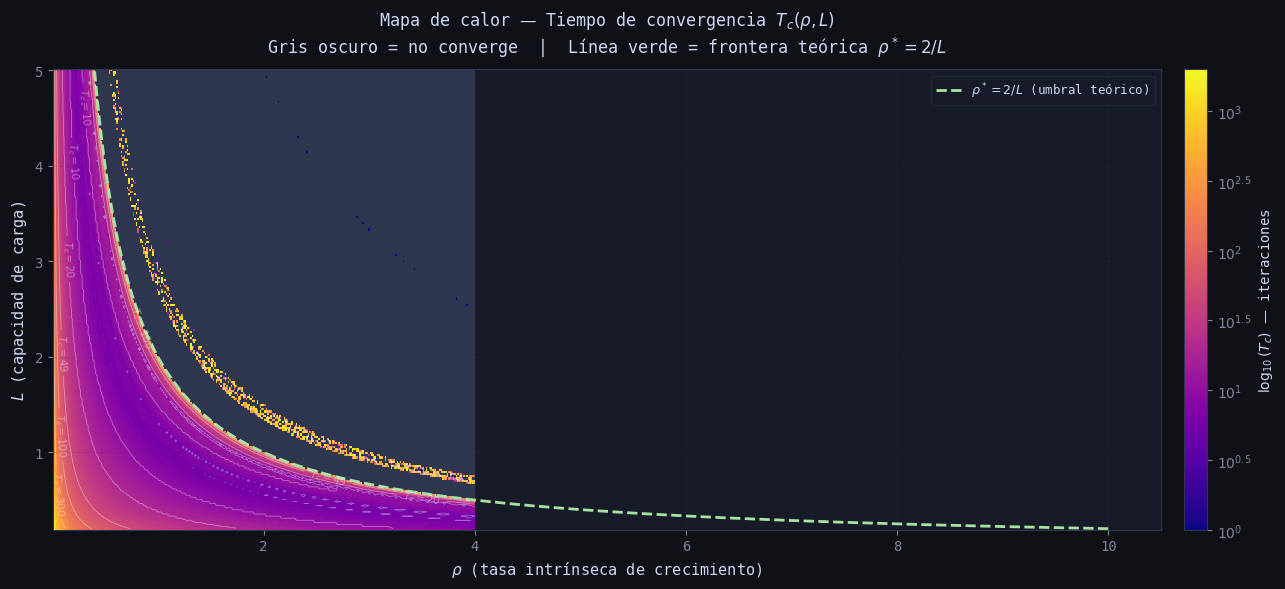

In [4]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0f1117')
ax.set_facecolor('#161b27')

# Colormap con NaN en gris oscuro
cmap_tc = plt.cm.plasma.copy()
cmap_tc.set_bad('#2e3650')   # color para zonas que no convergen

# Escala logarítmica para comprimir los tiempos largos
TC_log = np.log10(np.where(np.isnan(TC), np.nan, np.clip(TC, 1, None)))

im = ax.pcolormesh(
    RHO, LL, TC_log,
    cmap=cmap_tc,
    shading='auto',
    rasterized=True
)

# Frontera teórica rho* = 2/L
ax.plot(rho_frontera, L_vals, color='#a6e3a1', lw=2.0, ls='--',
        label=r'$\rho^* = 2/L$ (umbral teórico)')

# Contornos de isotiempos (en escala log)
niveles = [np.log10(t) for t in [5, 10, 20, 50, 100, 300]]
CS = ax.contour(
    RHO, LL, TC_log,
    levels=niveles,
    colors='white', linewidths=0.6, alpha=0.4
)
ax.clabel(CS, fmt=lambda v: f'$T_c={int(10**v)}$', fontsize=7.5,
          inline=True, inline_spacing=4)

# Colorbar
cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cb.set_label(r'$\log_{10}(T_c)$ — iteraciones', fontsize=10)
ticks_log = [0, 0.5, 1, 1.5, 2, 2.5, 3]
cb.set_ticks(ticks_log)
cb.set_ticklabels([f'$10^{{{t}}}$' if t == int(t) else f'$10^{{{t}}}$'
                   for t in ticks_log])
cb.ax.tick_params(colors='#7f849c')

ax.set_xlabel(r'$\rho$ (tasa intrínseca de crecimiento)', fontsize=11)
ax.set_ylabel(r'$L$ (capacidad de carga)', fontsize=11)
ax.set_title(
    r'Mapa de calor — Tiempo de convergencia $T_c(\rho, L)$' + '\n'
    r'Gris oscuro = no converge  |  Línea verde = frontera teórica $\rho^*=2/L$',
    pad=12
)
ax.legend(fontsize=9, framealpha=0.25, edgecolor='#45475a', loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 4. Mapa de regímenes dinámicos

Clasificación por el valor de $\rho L$:

| Régimen | Condición | Color |
|---------|-----------|-------|
| Estable monótono | $0 < \rho L < 1$ | Azul |
| Estable oscilatorio | $1 \leq \rho L < 2$ | Verde |
| Inestable / caos | $\rho L \geq 2$ | Rojo |

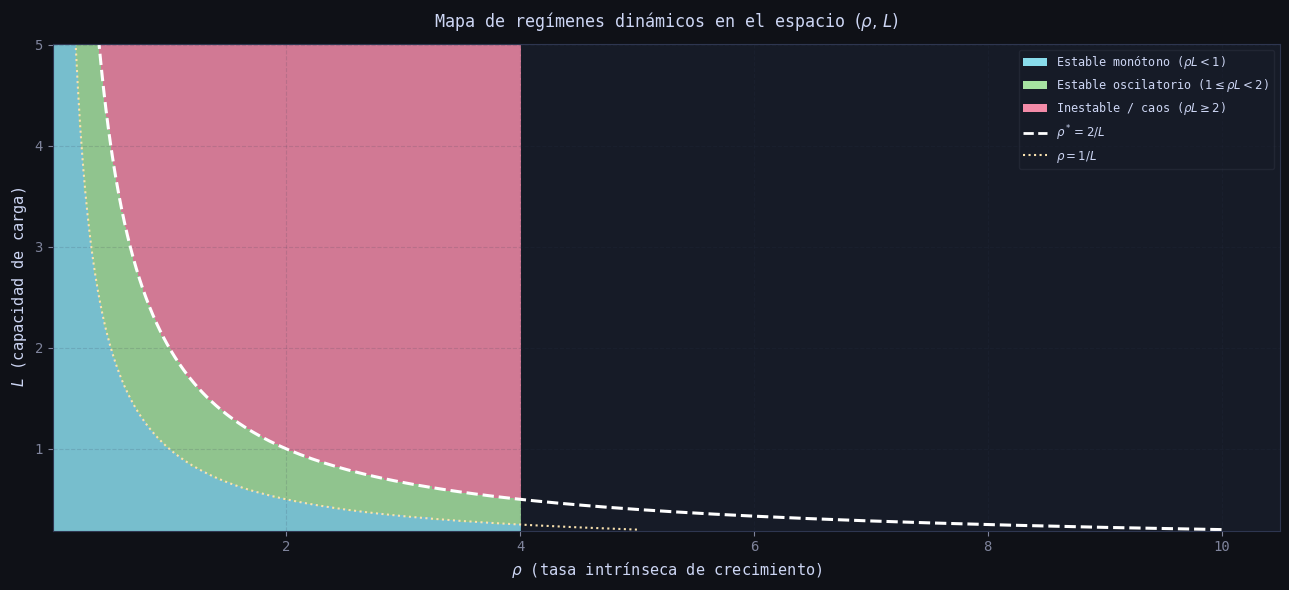

In [5]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0f1117')
ax.set_facecolor('#161b27')

# Colormap discreto de 3 colores
colores_reg = ['#89dceb', '#a6e3a1', '#f38ba8']  # azul, verde, rojo
cmap_reg    = mcolors.ListedColormap(colores_reg)
bounds      = [-0.5, 0.5, 1.5, 2.5]
norm_reg    = mcolors.BoundaryNorm(bounds, cmap_reg.N)

im2 = ax.pcolormesh(
    RHO, LL, REG,
    cmap=cmap_reg, norm=norm_reg,
    shading='auto', rasterized=True, alpha=0.85
)

# Frontera rho*=2/L
ax.plot(rho_frontera, L_vals, color='white', lw=2.2, ls='--',
        label=r'$\rho^* = 2/L$')
# Frontera rho=1/L (separación monótono / oscilatorio)
ax.plot(1.0 / L_vals, L_vals, color='#f9e2af', lw=1.5, ls=':',
        label=r'$\rho = 1/L$ (monótono ↔ oscilatorio)')

# Leyenda manual
leyenda = [
    Patch(facecolor='#89dceb', label='Estable monótono ($\\rho L < 1$)'),
    Patch(facecolor='#a6e3a1', label='Estable oscilatorio ($1 \\leq \\rho L < 2$)'),
    Patch(facecolor='#f38ba8', label='Inestable / caos ($\\rho L \\geq 2$)'),
    Line2D([0], [0], color='white',    lw=2, ls='--', label=r'$\rho^* = 2/L$'),
    Line2D([0], [0], color='#f9e2af', lw=1.5, ls=':', label=r'$\rho = 1/L$'),
]
ax.legend(handles=leyenda, fontsize=8.5, framealpha=0.25,
          edgecolor='#45475a', loc='upper right')

ax.set_xlabel(r'$\rho$ (tasa intrínseca de crecimiento)', fontsize=11)
ax.set_ylabel(r'$L$ (capacidad de carga)', fontsize=11)
ax.set_title(
    r'Mapa de regímenes dinámicos en el espacio $(\rho,\, L)$',
    pad=12
)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

---
## 5. Tasa de decaimiento $\lambda(\rho, L) = \log|1 - \rho L|$

$\lambda < 0$: contracción (convergencia). Cuanto más negativo, más rápido converge.  
$\lambda = 0$: umbral crítico.  
$\lambda > 0$: expansión (inestabilidad).

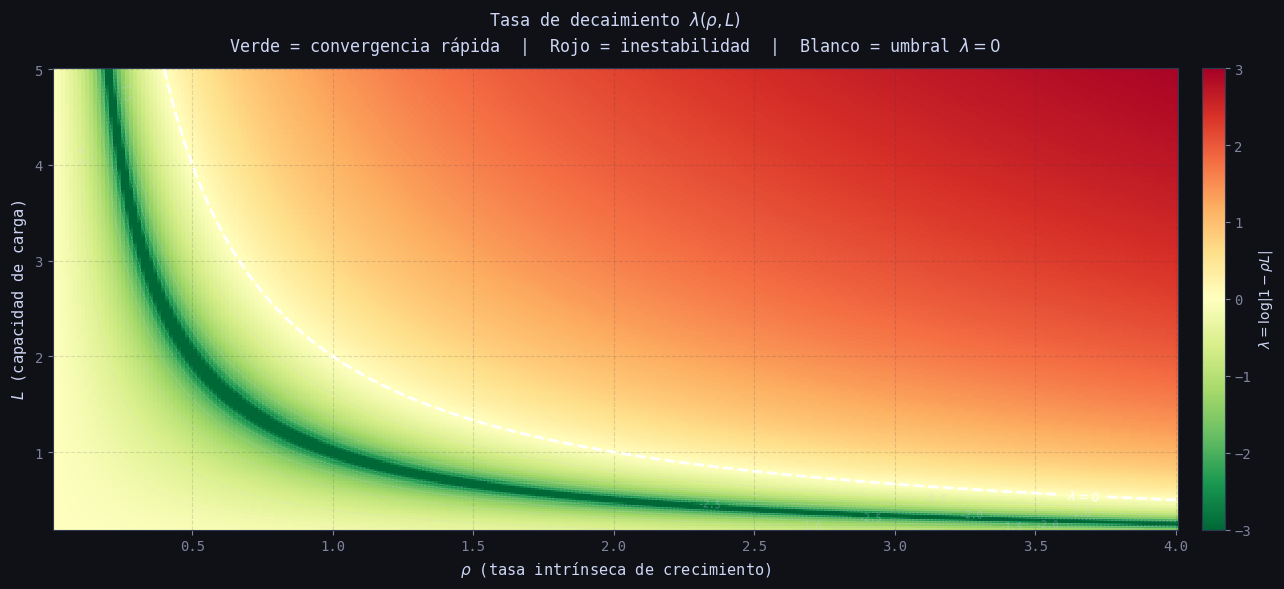

In [6]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0f1117')
ax.set_facecolor('#161b27')

# Recortar lambda para que la escala sea legible
LAM_clip = np.clip(LAMBDA, -3, 3)

# Colormap divergente centrado en 0
cmap_lam = plt.cm.RdYlGn_r   # rojo=inestable, verde=estable
norm_lam  = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

im3 = ax.pcolormesh(
    RHO, LL, LAM_clip,
    cmap=cmap_lam, norm=norm_lam,
    shading='auto', rasterized=True
)

# Contorno lambda=0 (frontera exacta)
CS0 = ax.contour(RHO, LL, LAMBDA, levels=[0],
                 colors='white', linewidths=2.0, linestyles='--')
ax.clabel(CS0, fmt=r'$\lambda=0$', fontsize=9, inline=True)

# Contornos de convergencia rápida
CS_neg = ax.contour(RHO, LL, LAM_clip,
                    levels=[-2.5, -2, -1.5, -1, -0.5],
                    colors='#cdd6f4', linewidths=0.5, alpha=0.35)
ax.clabel(CS_neg, fmt='%.1f', fontsize=7, inline=True)

cb3 = fig.colorbar(im3, ax=ax, pad=0.02, fraction=0.03)
cb3.set_label(r'$\lambda = \log|1 - \rho L|$', fontsize=10)
cb3.ax.tick_params(colors='#7f849c')

ax.set_xlabel(r'$\rho$ (tasa intrínseca de crecimiento)', fontsize=11)
ax.set_ylabel(r'$L$ (capacidad de carga)', fontsize=11)
ax.set_title(
    r'Tasa de decaimiento $\lambda(\rho, L)$' + '\n'
    r'Verde = convergencia rápida  |  Rojo = inestabilidad  |  Blanco = umbral $\lambda=0$',
    pad=12
)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

---
## 6. Amplitud de oscilación asintótica

Mide el rango $\max(X_n) - \min(X_n)$ tras descartar el transitorio.  
En la zona estable debería ser $\approx 0$. Valores altos indican oscilaciones persistentes o caos.

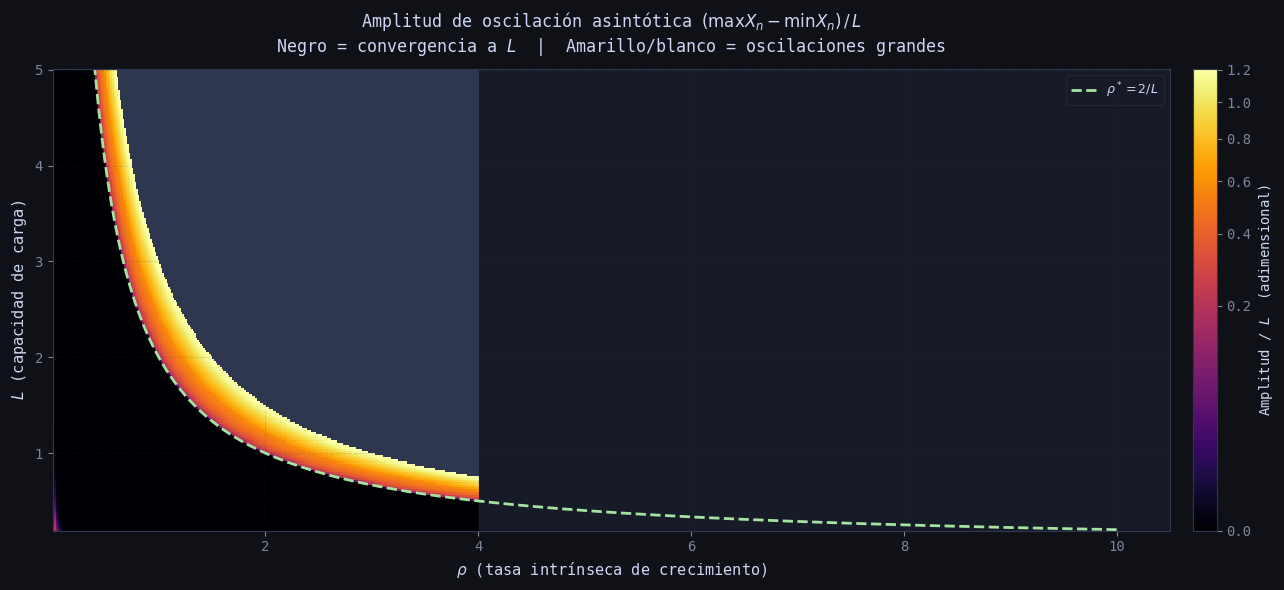

In [7]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0f1117')
ax.set_facecolor('#161b27')

cmap_amp = plt.cm.inferno.copy()
cmap_amp.set_bad('#2e3650')

# Normalizar amplitud por L para hacerla adimensional
AMPLI_norm = AMPLI / LL

im4 = ax.pcolormesh(
    RHO, LL, AMPLI_norm,
    cmap=cmap_amp,
    norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=np.nanpercentile(AMPLI_norm, 98)),
    shading='auto', rasterized=True
)

# Frontera teórica
ax.plot(rho_frontera, L_vals, color='#a6e3a1', lw=2.0, ls='--',
        label=r'$\rho^* = 2/L$')

cb4 = fig.colorbar(im4, ax=ax, pad=0.02, fraction=0.03)
cb4.set_label(r'Amplitud / $L$  (adimensional)', fontsize=10)
cb4.ax.tick_params(colors='#7f849c')

ax.set_xlabel(r'$\rho$ (tasa intrínseca de crecimiento)', fontsize=11)
ax.set_ylabel(r'$L$ (capacidad de carga)', fontsize=11)
ax.set_title(
    r'Amplitud de oscilación asintótica $(\max X_n - \min X_n)\,/\,L$' + '\n'
    r'Negro = convergencia a $L$  |  Amarillo/blanco = oscilaciones grandes',
    pad=12
)
ax.legend(fontsize=9, framealpha=0.25, edgecolor='#45475a')
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

---
## 7. Panel resumen — Las 4 métricas juntas

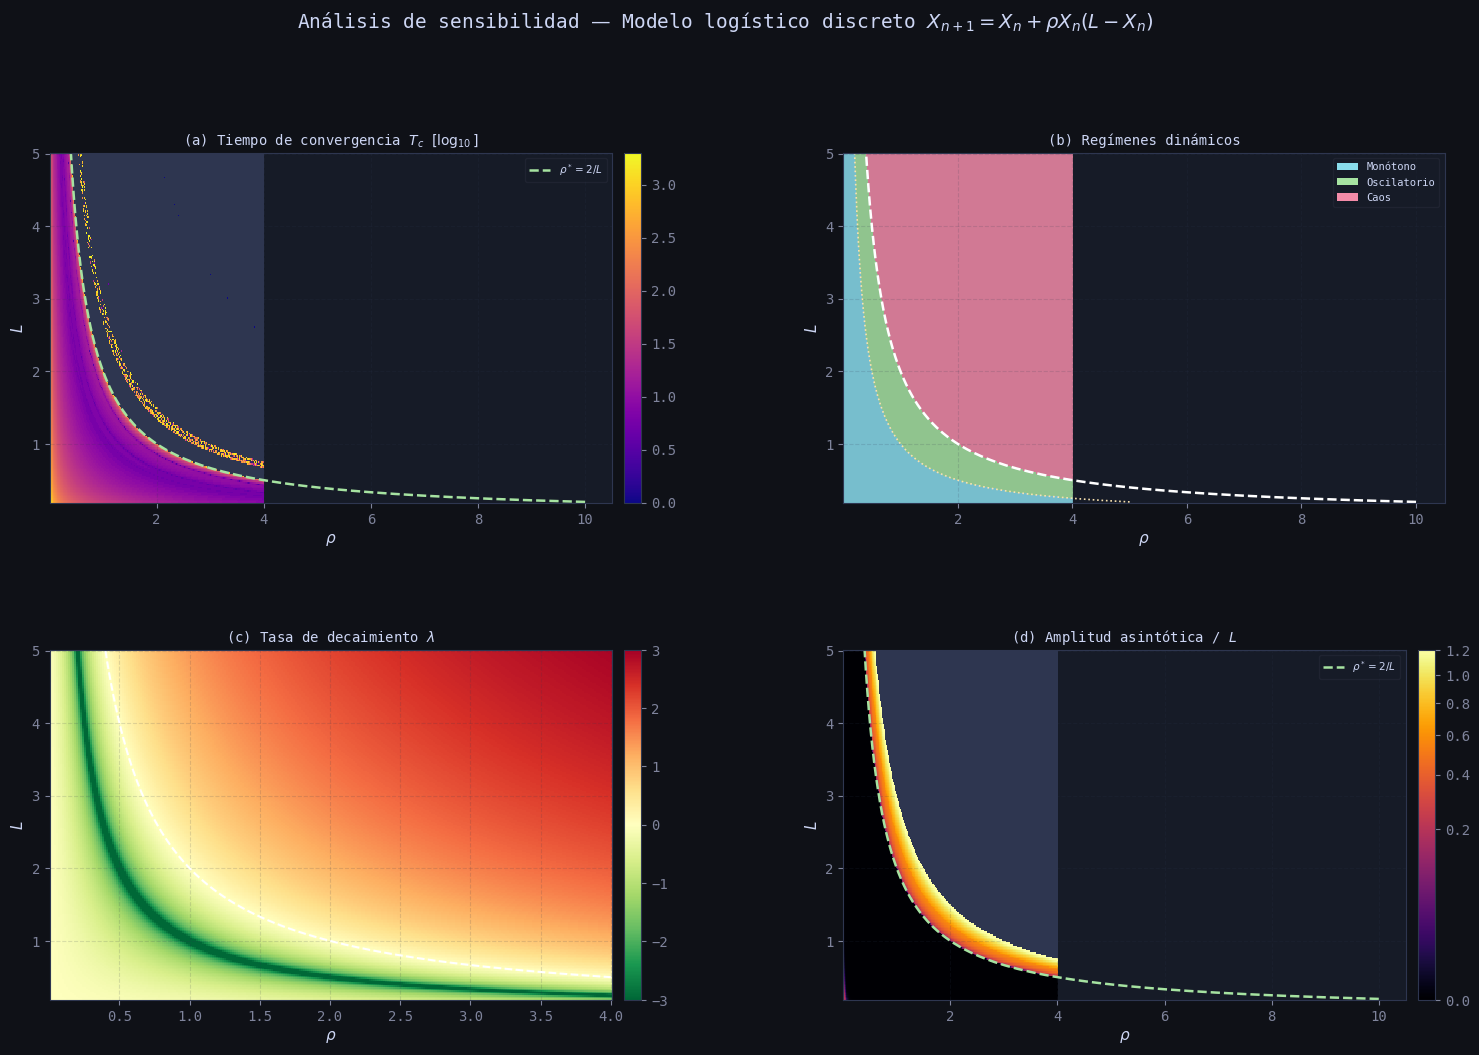

In [8]:
fig = plt.figure(figsize=(18, 11), facecolor='#0f1117')
fig.suptitle(
    r'Análisis de sensibilidad — Modelo logístico discreto $X_{n+1}=X_n+\rho X_n(L-X_n)$',
    fontsize=14, color='#cdd6f4', y=1.01
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

titulos = [
    r'(a) Tiempo de convergencia $T_c$ $[\log_{10}]$',
    r'(b) Regímenes dinámicos',
    r'(c) Tasa de decaimiento $\lambda$',
    r'(d) Amplitud asintótica / $L$',
]

# ── (a) Tiempo de convergencia ───────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor('#161b27')
cmap_a = plt.cm.plasma.copy(); cmap_a.set_bad('#2e3650')
im_a = ax_a.pcolormesh(RHO, LL, TC_log, cmap=cmap_a, shading='auto', rasterized=True)
ax_a.plot(rho_frontera, L_vals, color='#a6e3a1', lw=1.8, ls='--', label=r'$\rho^*=2/L$')
fig.colorbar(im_a, ax=ax_a, fraction=0.045, pad=0.02).ax.tick_params(colors='#7f849c')
ax_a.set_title(titulos[0], fontsize=10); ax_a.set_xlabel(r'$\rho$'); ax_a.set_ylabel('$L$')
ax_a.legend(fontsize=7.5, framealpha=0.2, edgecolor='#45475a')
ax_a.grid(True, alpha=0.15)

# ── (b) Regímenes ────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor('#161b27')
im_b = ax_b.pcolormesh(RHO, LL, REG, cmap=cmap_reg, norm=norm_reg,
                        shading='auto', rasterized=True, alpha=0.85)
ax_b.plot(rho_frontera, L_vals, color='white',   lw=1.8, ls='--', label=r'$\rho^*=2/L$')
ax_b.plot(1.0/L_vals,   L_vals, color='#f9e2af', lw=1.2, ls=':', label=r'$\rho=1/L$')
ley_b = [
    Patch(facecolor='#89dceb', label='Monótono'),
    Patch(facecolor='#a6e3a1', label='Oscilatorio'),
    Patch(facecolor='#f38ba8', label='Caos'),
]
ax_b.legend(handles=ley_b, fontsize=7.5, framealpha=0.2, edgecolor='#45475a')
ax_b.set_title(titulos[1], fontsize=10); ax_b.set_xlabel(r'$\rho$'); ax_b.set_ylabel('$L$')
ax_b.grid(True, alpha=0.15)

# ── (c) Tasa de decaimiento ──────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_facecolor('#161b27')
im_c = ax_c.pcolormesh(RHO, LL, LAM_clip, cmap=cmap_lam, norm=norm_lam,
                        shading='auto', rasterized=True)
ax_c.contour(RHO, LL, LAMBDA, levels=[0], colors='white', linewidths=1.5, linestyles='--')
fig.colorbar(im_c, ax=ax_c, fraction=0.045, pad=0.02).ax.tick_params(colors='#7f849c')
ax_c.set_title(titulos[2], fontsize=10); ax_c.set_xlabel(r'$\rho$'); ax_c.set_ylabel('$L$')
ax_c.grid(True, alpha=0.15)

# ── (d) Amplitud ─────────────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d.set_facecolor('#161b27')
im_d = ax_d.pcolormesh(
    RHO, LL, AMPLI_norm, cmap=cmap_amp,
    norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=np.nanpercentile(AMPLI_norm, 98)),
    shading='auto', rasterized=True
)
ax_d.plot(rho_frontera, L_vals, color='#a6e3a1', lw=1.8, ls='--', label=r'$\rho^*=2/L$')
fig.colorbar(im_d, ax=ax_d, fraction=0.045, pad=0.02).ax.tick_params(colors='#7f849c')
ax_d.set_title(titulos[3], fontsize=10); ax_d.set_xlabel(r'$\rho$'); ax_d.set_ylabel('$L$')
ax_d.legend(fontsize=7.5, framealpha=0.2, edgecolor='#45475a')
ax_d.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

---